# 02. RFM 기반 고객 세분화 (K-means 군집분석)

**개인팀(황채원)** 

RFM(Recency·Frequency·Monetary)은 고객 가치를 측정하는 대표적 프레임워크다.
- **Recency(최근성)** = 최근주문경과일 (작을수록 우수)
- **Frequency(구매빈도)** = 월평균주문수 × 가입개월수 (누적 주문 추정)
- **Monetary(구매금액)** = 누적결제금액

K-means 군집으로 고객을 그룹화하고, 그룹별 이탈률·특성을 해석하여
**타깃 마케팅(VIP 유지 / 휴면 방지 / 신규 육성) 전략**을 제안한다.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'   # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

df = pd.read_csv('사용 데이터/고객_구독_데이터.csv')
print('데이터 shape:', df.shape)
df.head()

데이터 shape: (9000, 20)


,고객ID,성별,연령,지역,가입채널,가입개월수,요금제,월요금,결제수단,자동결제여부,월평균로그인수,월평균주문수,평균주문금액,누적결제금액,최근주문경과일,CS문의수,만족도점수,쿠폰사용률,모바일사용비중,이탈여부
0,C100000,남,44,서울,SNS,30,Standard,19900,신용카드,1,14,1.1,34700,1145100,0,0,4.4,0.248,0.888,0
1,C100001,남,42,경기,검색광고,11,Premium,34900,체크카드,0,21,6.0,34500,2277000,18,2,4.0,0.322,0.802,0
2,C100002,남,34,부산,SNS,34,Basic,9900,간편결제,1,22,3.7,28600,3597900,0,0,3.9,0.294,0.918,0
3,C100003,남,28,인천,지인추천,13,Premium,34900,신용카드,1,11,3.2,34300,1426900,9,1,3.5,0.512,0.781,0
4,C100004,남,35,광주,검색광고,47,Basic,9900,간편결제,1,13,5.1,32000,7670400,85,1,1.9,0.600,0.764,1


In [2]:
for c in ['만족도점수','쿠폰사용률','모바일사용비중']:
    df[c] = df[c].fillna(df[c].median())

rfm = pd.DataFrame({
    '고객ID': df['고객ID'],
    'Recency': df['최근주문경과일'],
    'Frequency': (df['월평균주문수'] * df['가입개월수']).round(1),
    'Monetary': df['누적결제금액'],
})
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,9000.0,2.190633e+01,2.287880e+01,0.0,4.0,15.0,33.0,180.0
Frequency,9000.0,4.900031e+01,4.733663e+01,0.2,17.6,34.5,64.6,589.5
Monetary,9000.0,1.674476e+06,1.842561e+06,7500.0,501150.0,1071350.0,2198800.0,27942300.0


## 1. RFM 점수화 (1~5점, 분위수 기반)
Recency는 낮을수록 좋으므로 점수를 역순으로 부여한다.

In [3]:
rfm['R점수'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F점수'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M점수'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM합계'] = rfm[['R점수','F점수','M점수']].sum(axis=1)
rfm.head()

,고객ID,Recency,Frequency,Monetary,R점수,F점수,M점수,RFM합계
0,C100000,0,33.0,1145100,5,3,3,11
1,C100001,18,66.0,2277000,3,4,4,11
2,C100002,0,125.8,3597900,5,5,5,15
3,C100003,9,41.6,1426900,4,3,4,11
4,C100004,85,239.7,7670400,1,5,5,11


## 2. 최적 군집 수(k) 탐색 — 엘보우 & 실루엣

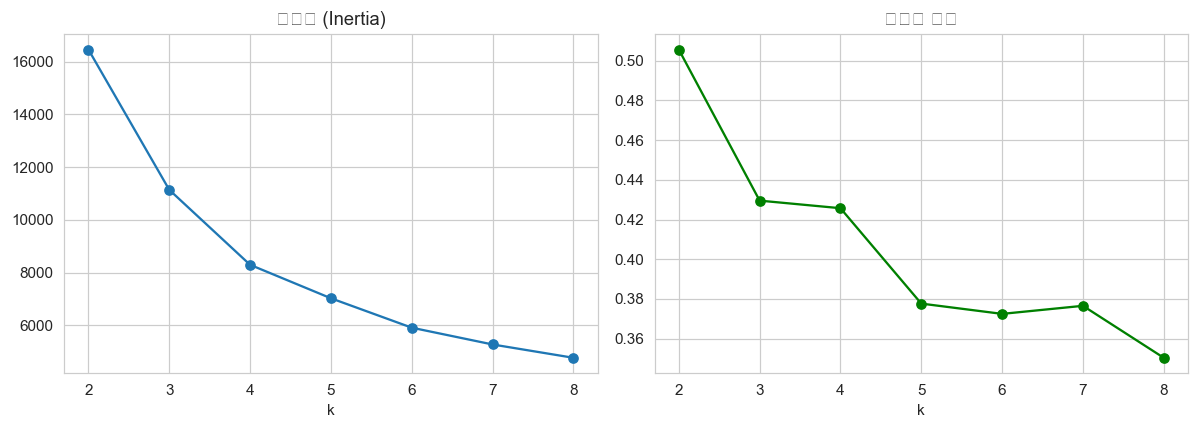

실루엣 최고 k = 2


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = StandardScaler().fit_transform(rfm[['Recency','Frequency','Monetary']])
inertia, sil = [], []
ks = range(2,9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertia.append(km.inertia_); sil.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(list(ks), inertia, 'o-'); ax[0].set_title('엘보우 (Inertia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sil, 'o-', color='green'); ax[1].set_title('실루엣 점수'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()
print('실루엣 최고 k =', list(ks)[int(np.argmax(sil))])

## 3. K-means 군집화 (k=4)
해석 용이성과 실루엣 점수를 고려해 4개 군집으로 세분화한다.

In [5]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['군집'] = km.fit_predict(X)
rfm = rfm.merge(df[['고객ID','이탈여부']], on='고객ID')

prof = rfm.groupby('군집').agg(
    고객수=('고객ID','count'),
    평균Recency=('Recency','mean'),
    평균Frequency=('Frequency','mean'),
    평균Monetary=('Monetary','mean'),
    이탈률=('이탈여부','mean')
).round(1)
prof['이탈률'] = (prof['이탈률']*100).round(1)
prof

,고객수,평균Recency,평균Frequency,평균Monetary,이탈률
군집,,,,,
0,4871,12.5,27.3,846651.7,10.0
1,360,17.7,201.2,7932334.4,10.0
2,1821,57.3,31.9,1019078.5,50.0
3,1948,13.0,91.1,3200647.6,10.0


## 4. 군집 라벨링 (비즈니스 해석)
Monetary·Frequency가 높고 Recency가 낮으면 우량, 그 반대면 위험/휴면 고객이다.

In [6]:
rank = prof.sort_values(['평균Monetary','평균Frequency'], ascending=False).index.tolist()
labels = {}
labels[rank[0]] = 'VIP 충성고객'
labels[rank[1]] = '성장 잠재고객'
labels[rank[-1]] = '휴면/이탈위험'
for c in rank[2:-1]:
    labels[c] = '일반 유지고객'
rfm['세그먼트'] = rfm['군집'].map(labels)
seg = rfm.groupby('세그먼트').agg(
    고객수=('고객ID','count'),
    평균Recency=('Recency','mean'),
    평균Frequency=('Frequency','mean'),
    평균Monetary=('Monetary','mean'),
    이탈률=('이탈여부','mean')).round(1)
seg['이탈률(%)'] = (seg['이탈률']*100).round(1); seg.drop(columns='이탈률', inplace=True)
seg

,고객수,평균Recency,평균Frequency,평균Monetary,이탈률(%)
세그먼트,,,,,
VIP 충성고객,360,17.7,201.2,7932334.4,10.0
성장 잠재고객,1948,13.0,91.1,3200647.6,10.0
일반 유지고객,1821,57.3,31.9,1019078.5,50.0
휴면/이탈위험,4871,12.5,27.3,846651.7,10.0


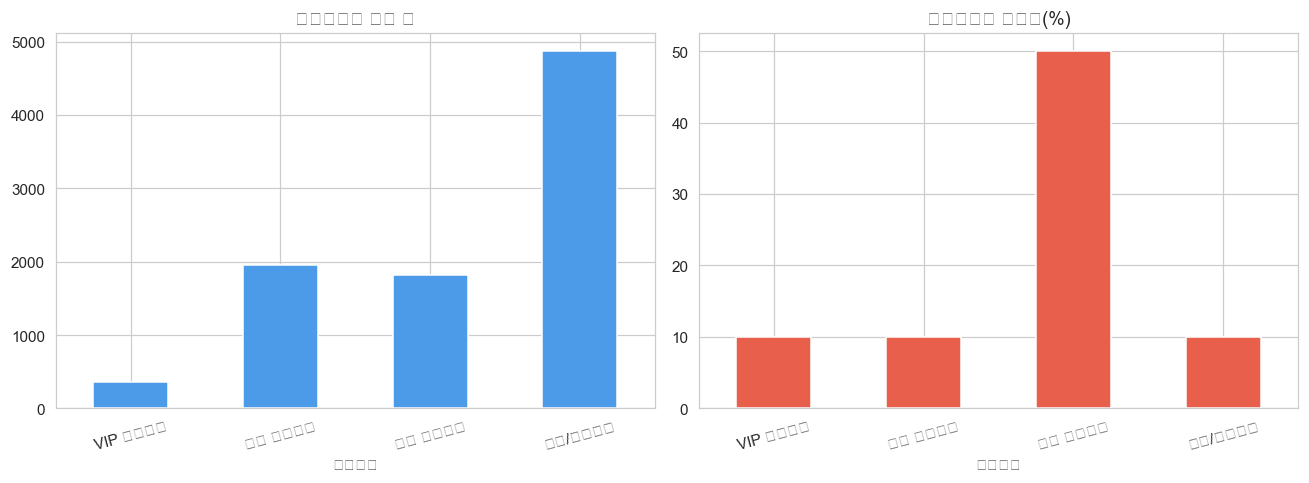

In [7]:
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
order = seg.sort_values('평균Monetary', ascending=False).index
seg.loc[order,'고객수'].plot(kind='bar', ax=ax[0], color='#4C9BE8')
ax[0].set_title('세그먼트별 고객 수'); ax[0].tick_params(axis='x', rotation=15)
seg.loc[order,'이탈률(%)'].plot(kind='bar', ax=ax[1], color='#E8604C')
ax[1].set_title('세그먼트별 이탈률(%)'); ax[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

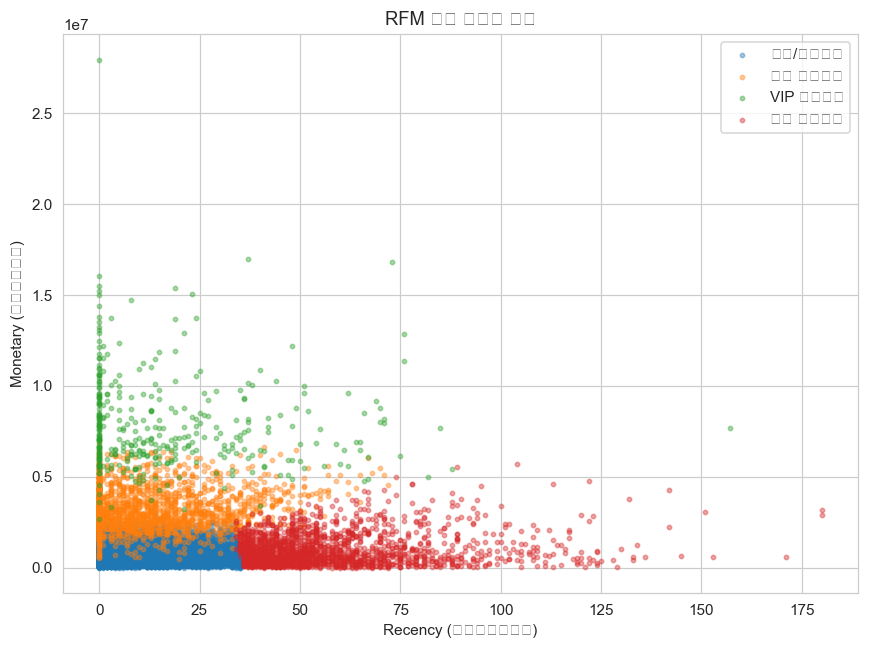

In [8]:
# 군집 산점도 (Recency vs Monetary)
plt.figure(figsize=(8,6))
for s in rfm['세그먼트'].unique():
    sub = rfm[rfm['세그먼트']==s]
    plt.scatter(sub['Recency'], sub['Monetary'], s=8, alpha=0.4, label=s)
plt.xlabel('Recency (최근주문경과일)'); plt.ylabel('Monetary (누적결제금액)')
plt.title('RFM 고객 세분화 결과'); plt.legend(); plt.tight_layout(); plt.show()

## 5. 세그먼트별 마케팅 전략 제안

| 세그먼트 | 특징 | 추천 액션 |
|---|---|---|
| **VIP 충성고객** | 고액·고빈도·최근 활동 활발 | 멤버십 등급 혜택·전용 프로모션으로 LTV 극대화 |
| **성장 잠재고객** | 구매력은 있으나 빈도 낮음 | 교차판매·번들 쿠폰으로 구매빈도 상향 |
| **일반 유지고객** | 평균 수준 | 정기 리마인드·시즌 캠페인으로 유지 |
| **휴면/이탈위험** | 장기 미구매·저빈도, 이탈률 최고 | **자동결제 전환 유도·위너백 쿠폰**으로 재활성화 |

➡ 세그먼트와 노트북 03의 **이탈확률 점수**를 결합하면
   "고가치 × 고위험" 고객을 우선 타깃하는 정밀 리텐션이 가능하다.

RFM 결과를 파일로 저장한다.

In [9]:
rfm.to_csv('사용 데이터/RFM_세분화결과.csv', index=False, encoding='utf-8-sig')
print('저장 완료: 사용 데이터/RFM_세분화결과.csv', rfm.shape)

저장 완료: 사용 데이터/RFM_세분화결과.csv (9000, 11)
